# Lab 5 (Laboratory work no. 7) - Greedy Algorithms: Prim vs Kruskal

## Subject
Greedy algorithms for Minimum Spanning Tree (MST) in weighted undirected graphs.

## Objectives
1. Study the greedy algorithm design technique.
2. Implement **Prim** and **Kruskal** in Python.
3. Perform empirical analysis of both algorithms.
4. Increase graph size and analyze impact; present data graphically.
5. Prepare a short report with conclusions.

## Notes
- We keep the same graph style used in previous labs: simple/random, complete, wheel, bipartite, regular, planar grid, tree, cycle, weighted.
- We test sparse and dense settings, for both few and many nodes.
- For disconnected graphs, implementations return a minimum spanning forest.

In [ ]:
%pip install matplotlib

In [1]:
import math
import random
import time
import heapq
from statistics import mean

import matplotlib.pyplot as plt

random.seed(42)
plt.style.use("seaborn-v0_8-whitegrid")

In [2]:
def _edge_key(u, v):
    return (u, v) if u < v else (v, u)


def _add_undirected_weighted_edge(edge_map, u, v, w):
    if u == v:
        return
    key = _edge_key(u, v)
    if key not in edge_map or w < edge_map[key]:
        edge_map[key] = w


def _max_undirected_edges(n):
    return n * (n - 1) // 2


def build_graph_structures(n, edge_map):
    edges = [(u, v, w) for (u, v), w in edge_map.items()]
    adj = [[] for _ in range(n)]
    for u, v, w in edges:
        adj[u].append((v, w))
        adj[v].append((u, w))

    m = len(edges)
    density = m / _max_undirected_edges(n) if n > 1 else 0.0
    return adj, edges, m, density


def generate_connected_random_weighted_graph(n, density, w_min=1, w_max=20):
    edge_map = {}

    # Start from a random tree so the graph is connected.
    for v in range(1, n):
        parent = random.randint(0, v - 1)
        _add_undirected_weighted_edge(edge_map, parent, v, random.randint(w_min, w_max))

    max_edges = _max_undirected_edges(n)
    target_m = max(n - 1, min(max_edges, int(round(density * max_edges))))

    while len(edge_map) < target_m:
        u = random.randrange(n)
        v = random.randrange(n)
        if u != v:
            _add_undirected_weighted_edge(edge_map, u, v, random.randint(w_min, w_max))

    return build_graph_structures(n, edge_map)


def generate_graph_family(n, family, density=0.3, w_min=1, w_max=20):
    edge_map = {}

    if family == "simple":
        return generate_connected_random_weighted_graph(n, density, w_min, w_max)

    if family == "complete":
        for u in range(n):
            for v in range(u + 1, n):
                _add_undirected_weighted_edge(edge_map, u, v, random.randint(w_min, w_max))
        return build_graph_structures(n, edge_map)

    if family == "cycle":
        for u in range(n):
            v = (u + 1) % n
            _add_undirected_weighted_edge(edge_map, u, v, random.randint(w_min, w_max))
        return build_graph_structures(n, edge_map)

    if family == "tree":
        for v in range(1, n):
            parent = random.randint(0, v - 1)
            _add_undirected_weighted_edge(edge_map, parent, v, random.randint(w_min, w_max))
        return build_graph_structures(n, edge_map)

    if family == "wheel":
        if n < 4:
            return generate_graph_family(n, "cycle", density, w_min, w_max)
        center = 0
        rim = list(range(1, n))
        for i in range(len(rim)):
            u = rim[i]
            v = rim[(i + 1) % len(rim)]
            _add_undirected_weighted_edge(edge_map, u, v, random.randint(w_min, w_max))
            _add_undirected_weighted_edge(edge_map, center, u, random.randint(w_min, w_max))
        return build_graph_structures(n, edge_map)

    if family == "bipartite":
        left = list(range(n // 2))
        right = list(range(n // 2, n))

        # Build a base alternating chain to keep the graph connected.
        chain = []
        for i in range(min(len(left), len(right))):
            chain.append(left[i])
            chain.append(right[i])
        if len(left) > len(right):
            chain.extend(left[len(right):])
        elif len(right) > len(left):
            chain.extend(right[len(left):])

        for i in range(len(chain) - 1):
            u, v = chain[i], chain[i + 1]
            _add_undirected_weighted_edge(edge_map, u, v, random.randint(w_min, w_max))

        p = min(1.0, max(0.05, density))
        for u in left:
            for v in right:
                if random.random() < p:
                    _add_undirected_weighted_edge(edge_map, u, v, random.randint(w_min, w_max))

        return build_graph_structures(n, edge_map)

    if family == "regular":
        k = 4 if n > 5 else 2
        for u in range(n):
            for shift in range(1, k // 2 + 1):
                v = (u + shift) % n
                _add_undirected_weighted_edge(edge_map, u, v, random.randint(w_min, w_max))
        return build_graph_structures(n, edge_map)

    if family == "grid":
        side = int(math.sqrt(n))
        side = max(2, side)
        n_grid = side * side
        for r in range(side):
            for c in range(side):
                u = r * side + c
                if c + 1 < side:
                    v = r * side + (c + 1)
                    _add_undirected_weighted_edge(edge_map, u, v, random.randint(w_min, w_max))
                if r + 1 < side:
                    v = (r + 1) * side + c
                    _add_undirected_weighted_edge(edge_map, u, v, random.randint(w_min, w_max))
        return build_graph_structures(n_grid, edge_map)

    if family == "weighted":
        # Same structure as random graph, with a broader weight interval.
        return generate_connected_random_weighted_graph(n, density, 1, 100)

    raise ValueError(f"Unknown family: {family}")

In [3]:
class DisjointSetUnion:
    def __init__(self, n):
        self.parent = list(range(n))
        self.rank = [0] * n

    def find(self, x):
        while self.parent[x] != x:
            self.parent[x] = self.parent[self.parent[x]]
            x = self.parent[x]
        return x

    def union(self, a, b):
        ra = self.find(a)
        rb = self.find(b)
        if ra == rb:
            return False

        if self.rank[ra] < self.rank[rb]:
            ra, rb = rb, ra

        self.parent[rb] = ra
        if self.rank[ra] == self.rank[rb]:
            self.rank[ra] += 1
        return True


def prim_mst(adj):
    n = len(adj)
    visited = [False] * n
    total = 0
    mst_edges = []
    accepted_weights = []

    for start in range(n):
        if visited[start]:
            continue

        visited[start] = True
        heap = []
        for v, w in adj[start]:
            heapq.heappush(heap, (w, start, v))

        while heap:
            w, u, v = heapq.heappop(heap)
            if visited[v]:
                continue

            visited[v] = True
            total += w
            mst_edges.append((u, v, w))
            accepted_weights.append(w)

            for to, wt in adj[v]:
                if not visited[to]:
                    heapq.heappush(heap, (wt, v, to))

    return total, mst_edges, accepted_weights


def kruskal_mst(n, edges):
    dsu = DisjointSetUnion(n)
    total = 0
    mst_edges = []
    accepted_weights = []

    for u, v, w in sorted(edges, key=lambda e: e[2]):
        if dsu.union(u, v):
            total += w
            mst_edges.append((u, v, w))
            accepted_weights.append(w)

    return total, mst_edges, accepted_weights

In [4]:
# How the MST is found (Prim vs Kruskal) — step-by-step on a small graph
# We use a fixed connected graph with UNIQUE weights so the choice order is deterministic.

# Graph (n=6) edges (u, v, w):
# 0-1(4), 0-2(3), 1-2(1), 1-3(2), 2-3(4), 2-4(6), 3-4(5), 3-5(7), 4-5(8)

n_ex = 6
edge_map_ex = {}
_add_undirected_weighted_edge(edge_map_ex, 0, 1, 4)
_add_undirected_weighted_edge(edge_map_ex, 0, 2, 3)
_add_undirected_weighted_edge(edge_map_ex, 1, 2, 1)
_add_undirected_weighted_edge(edge_map_ex, 1, 3, 2)
_add_undirected_weighted_edge(edge_map_ex, 2, 3, 4)
_add_undirected_weighted_edge(edge_map_ex, 2, 4, 6)
_add_undirected_weighted_edge(edge_map_ex, 3, 4, 5)
_add_undirected_weighted_edge(edge_map_ex, 3, 5, 7)
_add_undirected_weighted_edge(edge_map_ex, 4, 5, 8)

adj_ex, edges_ex, m_ex, d_ex = build_graph_structures(n_ex, edge_map_ex)
print(f"Example graph: n={n_ex}, m={m_ex}, density={d_ex:.3f}")
print("Edges (unsorted):", sorted(edges_ex, key=lambda e: (e[2], e[0], e[1])))

# Prim: grows ONE tree by repeatedly adding the lightest edge that connects
# the current visited set to an unvisited vertex (frontier-min edge).
prim_total_ex, prim_edges_ex, _ = prim_mst(adj_ex)
print("\nPrim (accepted edges in order):")
run = 0
for i, (u, v, w) in enumerate(prim_edges_ex, 1):
    run += w
    print(f"  step {i}: add edge ({u}-{v}) w={w} -> cumulative={run}")
print("Prim total MST weight:", prim_total_ex)

# Kruskal: sorts ALL edges globally by weight, then scans them from smallest to largest,
# accepting an edge iff it does NOT create a cycle (checked with DSU / Union-Find).

def kruskal_trace(n, edges):
    dsu = DisjointSetUnion(n)
    accepted = []
    rejected = []
    total = 0

    for (u, v, w) in sorted(edges, key=lambda e: (e[2], e[0], e[1])):
        if dsu.union(u, v):
            accepted.append((u, v, w))
            total += w
        else:
            rejected.append((u, v, w))

    return total, accepted, rejected

kr_total_ex, kr_acc_ex, kr_rej_ex = kruskal_trace(n_ex, edges_ex)
print("\nKruskal (edge scan order; accept/reject):")
# Print just enough to show the idea (small graph, so we can print all)
for (u, v, w) in sorted(edges_ex, key=lambda e: (e[2], e[0], e[1])):
    decision = "ACCEPT" if (u, v, w) in kr_acc_ex else "REJECT (cycle)"
    print(f"  consider ({u}-{v}) w={w:2d} -> {decision}")

print("\nKruskal (accepted edges in order):")
run = 0
for i, (u, v, w) in enumerate(kr_acc_ex, 1):
    run += w
    print(f"  step {i}: add edge ({u}-{v}) w={w} -> cumulative={run}")
print("Kruskal total MST weight:", kr_total_ex)

print("\nSame MST total weight (Prim vs Kruskal):", abs(prim_total_ex - kr_total_ex) < 1e-9)

Example graph: n=6, m=9, density=0.600
Edges (unsorted): [(1, 2, 1), (1, 3, 2), (0, 2, 3), (0, 1, 4), (2, 3, 4), (3, 4, 5), (2, 4, 6), (3, 5, 7), (4, 5, 8)]

Prim (accepted edges in order):
  step 1: add edge (0-2) w=3 -> cumulative=3
  step 2: add edge (2-1) w=1 -> cumulative=4
  step 3: add edge (1-3) w=2 -> cumulative=6
  step 4: add edge (3-4) w=5 -> cumulative=11
  step 5: add edge (3-5) w=7 -> cumulative=18
Prim total MST weight: 18

Kruskal (edge scan order; accept/reject):
  consider (1-2) w= 1 -> ACCEPT
  consider (1-3) w= 2 -> ACCEPT
  consider (0-2) w= 3 -> ACCEPT
  consider (0-1) w= 4 -> REJECT (cycle)
  consider (2-3) w= 4 -> REJECT (cycle)
  consider (3-4) w= 5 -> ACCEPT
  consider (2-4) w= 6 -> REJECT (cycle)
  consider (3-5) w= 7 -> ACCEPT
  consider (4-5) w= 8 -> REJECT (cycle)

Kruskal (accepted edges in order):
  step 1: add edge (1-2) w=1 -> cumulative=1
  step 2: add edge (1-3) w=2 -> cumulative=3
  step 3: add edge (0-2) w=3 -> cumulative=6
  step 4: add edge (3-4

In [4]:
def time_function(fn, *args, repeats=3, **kwargs):
    times = []
    result = None
    for _ in range(repeats):
        t0 = time.perf_counter()
        result = fn(*args, **kwargs)
        t1 = time.perf_counter()
        times.append(t1 - t0)
    return mean(times), result


def benchmark_case(adj, edges, repeats=3):
    n = len(adj)

    prim_t, prim_res = time_function(prim_mst, adj, repeats=repeats)
    kruskal_t, kruskal_res = time_function(kruskal_mst, n, edges, repeats=repeats)

    prim_total, prim_edges, _ = prim_res
    kr_total, kr_edges, _ = kruskal_res

    return {
        "prim_s": prim_t,
        "kruskal_s": kruskal_t,
        "speedup_prim_over_kruskal": (kruskal_t / prim_t) if prim_t > 0 else float("inf"),
        "same_total_weight": abs(prim_total - kr_total) < 1e-9,
        "prim_total": prim_total,
        "kruskal_total": kr_total,
        "prim_edges": len(prim_edges),
        "kruskal_edges": len(kr_edges),
    }


def run_scale_experiment(node_sizes, densities, repeats=2):
    rows = []
    for density in densities:
        for n in node_sizes:
            adj, edges, m, real_density = generate_connected_random_weighted_graph(n, density)
            bench = benchmark_case(adj, edges, repeats=repeats)
            rows.append({
                "family": "simple",
                "n": n,
                "m": m,
                "density": real_density,
                "target_density": density,
                **bench,
            })
    return rows


def run_family_experiment(n=120, density=0.35, repeats=2):
    families = ["simple", "complete", "wheel", "bipartite", "regular", "grid", "tree", "cycle", "weighted"]
    rows = []
    for fam in families:
        adj, edges, m, real_density = generate_graph_family(n, fam, density=density)
        n_eff = len(adj)
        bench = benchmark_case(adj, edges, repeats=repeats)
        rows.append({
            "family": fam,
            "n": n_eff,
            "m": m,
            "density": real_density,
            **bench,
        })
    return rows

In [5]:
def circular_layout(n, radius=1.0):
    pos = {}
    for i in range(n):
        theta = 2 * math.pi * i / n
        pos[i] = (radius * math.cos(theta), radius * math.sin(theta))
    return pos


def draw_graph_and_mst(n, edges, mst_edges, title):
    pos = circular_layout(n)
    mst_set = {(_edge_key(u, v), w) for u, v, w in mst_edges}

    plt.figure(figsize=(7, 7))

    for u, v, w in edges:
        x1, y1 = pos[u]
        x2, y2 = pos[v]
        if ((_edge_key(u, v), w)) in mst_set:
            plt.plot([x1, x2], [y1, y2], color="crimson", linewidth=2.6, alpha=0.95)
        else:
            plt.plot([x1, x2], [y1, y2], color="gray", linewidth=1.0, alpha=0.35)

    xs = [pos[i][0] for i in range(n)]
    ys = [pos[i][1] for i in range(n)]
    plt.scatter(xs, ys, s=140, color="#1f77b4", edgecolors="white", linewidths=1.0, zorder=3)

    if n <= 25:
        for i in range(n):
            plt.text(pos[i][0], pos[i][1], str(i), fontsize=9, ha="center", va="center", color="white", zorder=4)

    plt.title(title)
    plt.axis("off")
    plt.tight_layout()
    plt.show()


def plot_cumulative_acceptance_trace(prim_weights, kruskal_weights):
    prim_cum = []
    s = 0
    for w in prim_weights:
        s += w
        prim_cum.append(s)

    kr_cum = []
    s = 0
    for w in kruskal_weights:
        s += w
        kr_cum.append(s)

    x1 = list(range(1, len(prim_cum) + 1))
    x2 = list(range(1, len(kr_cum) + 1))

    plt.figure(figsize=(8, 4))
    plt.plot(x1, prim_cum, marker="o", label="Prim (accepted edges order)")
    plt.plot(x2, kr_cum, marker="s", label="Kruskal (accepted edges order)")
    plt.xlabel("Accepted edge index")
    plt.ylabel("Cumulative MST weight")
    plt.title("How Greedy Choices Build the Final MST")
    plt.legend()
    plt.tight_layout()
    plt.show()

Visualization graph: n=6, m=9, density=0.600
Prim total=18, Kruskal total=18, same=True


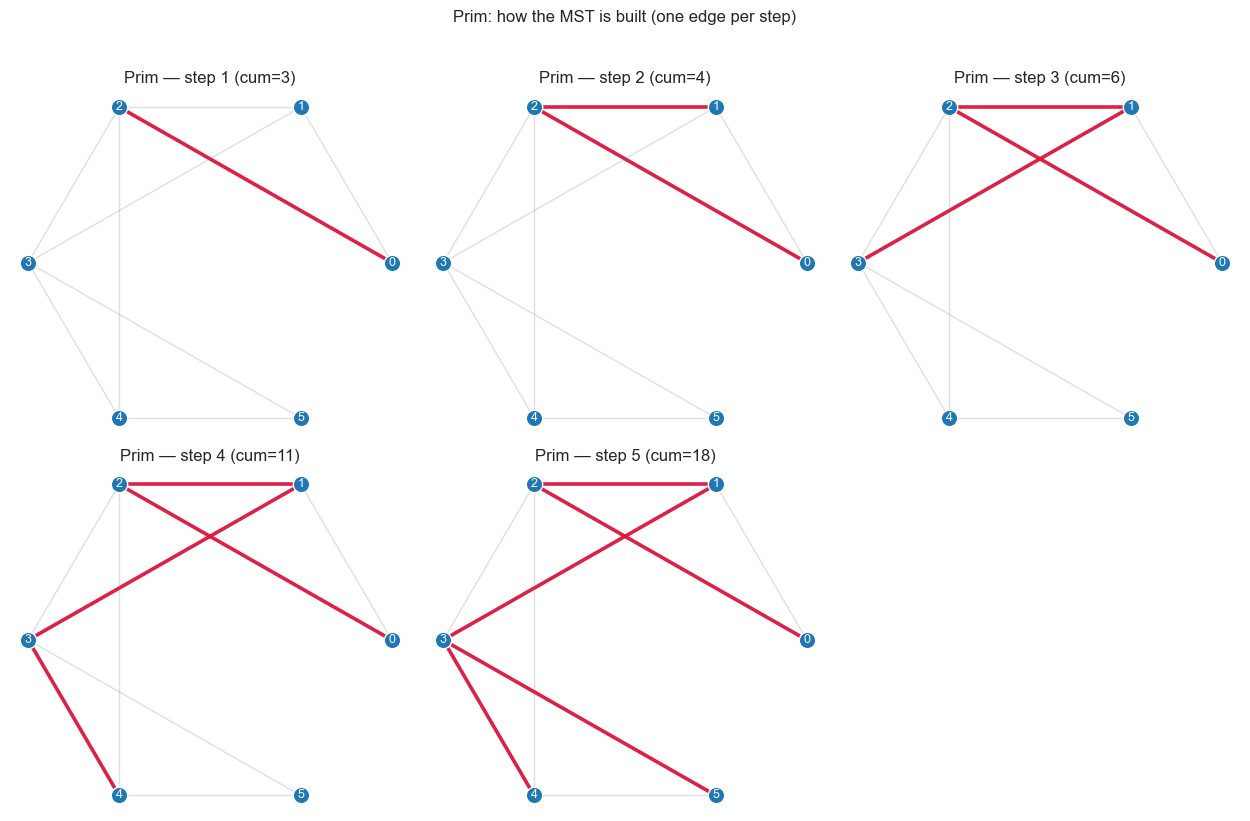

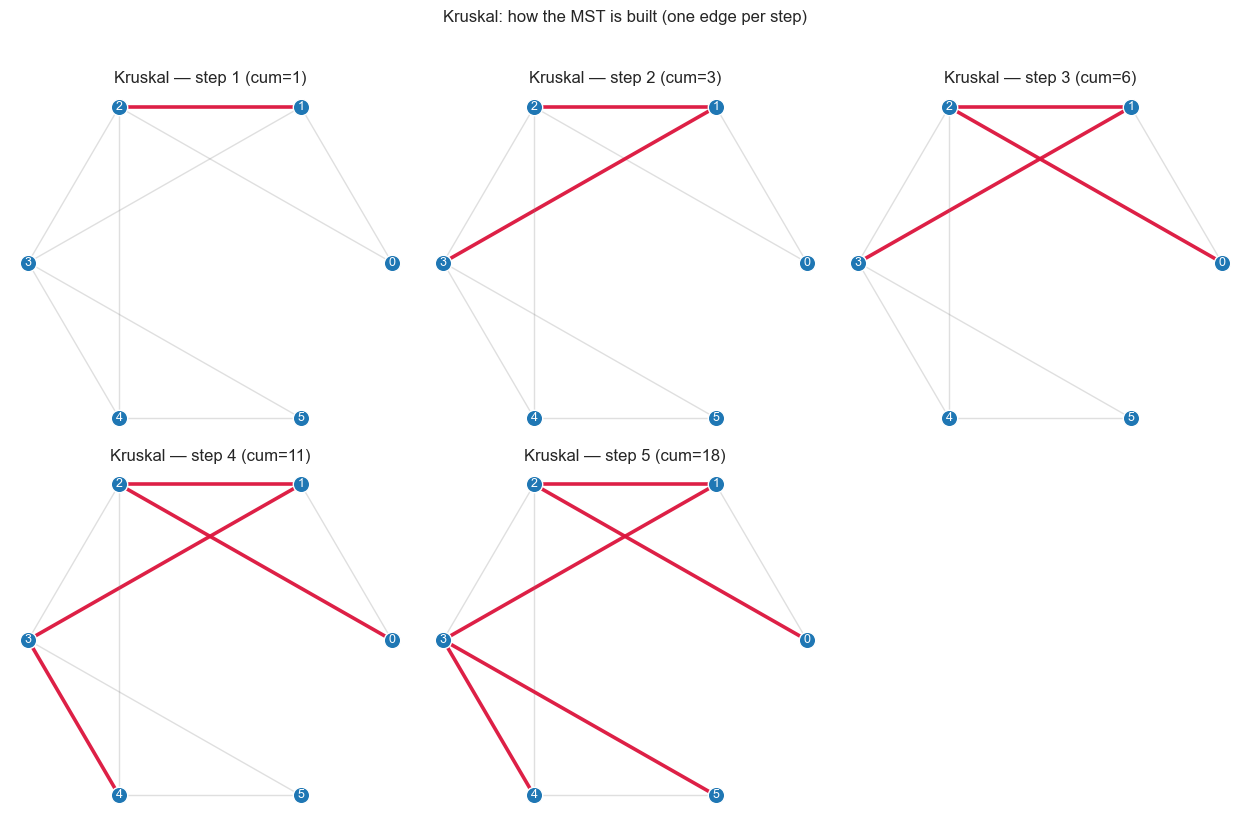

In [6]:
# Visualization: step-by-step MST construction (Prim vs Kruskal)
# Uses the same small fixed example graph from the trace cell.

# (Re)build the same example graph locally to keep this cell runnable on its own.
n_vis = 6
edge_map_vis = {}
_add_undirected_weighted_edge(edge_map_vis, 0, 1, 4)
_add_undirected_weighted_edge(edge_map_vis, 0, 2, 3)
_add_undirected_weighted_edge(edge_map_vis, 1, 2, 1)
_add_undirected_weighted_edge(edge_map_vis, 1, 3, 2)
_add_undirected_weighted_edge(edge_map_vis, 2, 3, 4)
_add_undirected_weighted_edge(edge_map_vis, 2, 4, 6)
_add_undirected_weighted_edge(edge_map_vis, 3, 4, 5)
_add_undirected_weighted_edge(edge_map_vis, 3, 5, 7)
_add_undirected_weighted_edge(edge_map_vis, 4, 5, 8)

adj_vis, edges_vis, m_vis, d_vis = build_graph_structures(n_vis, edge_map_vis)

# Get the edge-acceptance order for each algorithm.
prim_total_vis, prim_edges_vis, _ = prim_mst(adj_vis)

# Kruskal acceptance order
_kr_total_vis, kr_edges_vis, _ = kruskal_mst(n_vis, edges_vis)

pos = circular_layout(n_vis)


def _draw_graph_with_chosen_edges(ax, n, edges, chosen_edges, title):
    chosen_keys = {_edge_key(u, v): w for (u, v, w) in chosen_edges}

    for u, v, w in edges:
        x1, y1 = pos[u]
        x2, y2 = pos[v]
        key = _edge_key(u, v)
        if key in chosen_keys and chosen_keys[key] == w:
            ax.plot([x1, x2], [y1, y2], color="crimson", linewidth=2.6, alpha=0.95)
        else:
            ax.plot([x1, x2], [y1, y2], color="gray", linewidth=1.0, alpha=0.25)

    xs = [pos[i][0] for i in range(n)]
    ys = [pos[i][1] for i in range(n)]
    ax.scatter(xs, ys, s=140, color="#1f77b4", edgecolors="white", linewidths=1.0, zorder=3)

    for i in range(n):
        ax.text(pos[i][0], pos[i][1], str(i), fontsize=9, ha="center", va="center", color="white", zorder=4)

    ax.set_title(title)
    ax.axis("off")


def _plot_steps(accepted_edges, algo_name):
    steps = len(accepted_edges)
    cols = 3
    rows = (steps + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(4.2 * cols, 4.0 * rows))
    axes_flat = axes.ravel() if hasattr(axes, "ravel") else [axes]

    for idx, ax in enumerate(axes_flat):
        if idx < steps:
            chosen = accepted_edges[: idx + 1]
            cum = sum(w for _, _, w in chosen)
            _draw_graph_with_chosen_edges(
                ax,
                n_vis,
                edges_vis,
                chosen,
                title=f"{algo_name} — step {idx+1} (cum={cum})",
            )
        else:
            ax.axis("off")

    plt.suptitle(f"{algo_name}: how the MST is built (one edge per step)", y=1.02)
    plt.tight_layout()
    plt.show()


print(f"Visualization graph: n={n_vis}, m={m_vis}, density={d_vis:.3f}")
print(f"Prim total={prim_total_vis}, Kruskal total={_kr_total_vis}, same={abs(prim_total_vis - _kr_total_vis) < 1e-9}")

_plot_steps(prim_edges_vis, "Prim")
_plot_steps(kr_edges_vis, "Kruskal")

Demo graph: n=14, m=25, density=0.275
Prim total = 74
Kruskal total = 74
Same total MST weight: True


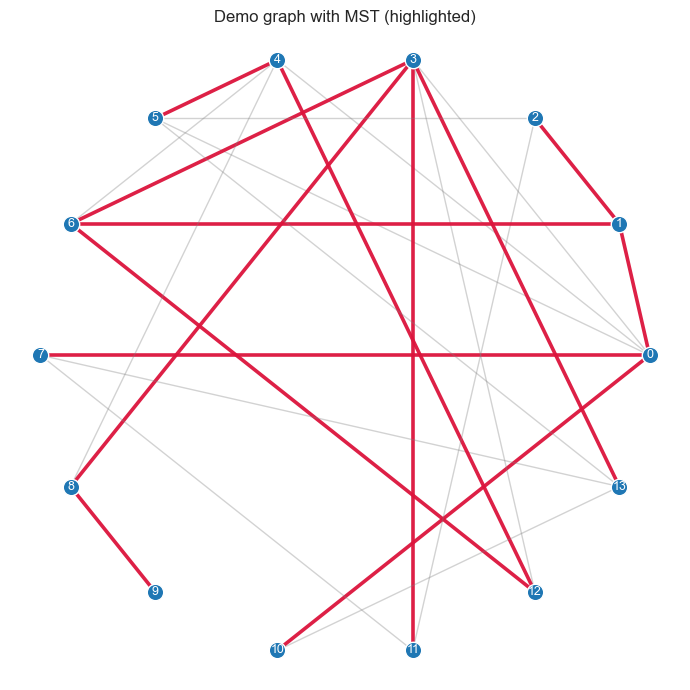

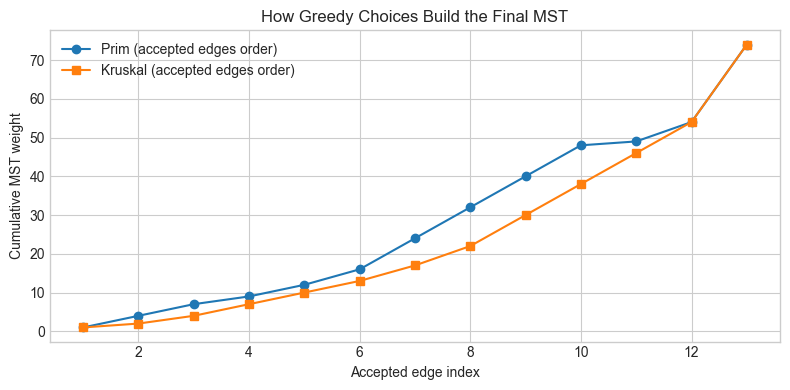

In [6]:
# Small visual demo (few nodes)
n_demo = 14
adj_demo, edges_demo, m_demo, d_demo = generate_graph_family(n_demo, "simple", density=0.28)

prim_total, prim_edges, prim_trace = prim_mst(adj_demo)
kr_total, kr_edges, kr_trace = kruskal_mst(len(adj_demo), edges_demo)

print(f"Demo graph: n={len(adj_demo)}, m={m_demo}, density={d_demo:.3f}")
print(f"Prim total = {prim_total}")
print(f"Kruskal total = {kr_total}")
print("Same total MST weight:", abs(prim_total - kr_total) < 1e-9)

draw_graph_and_mst(len(adj_demo), edges_demo, prim_edges, "Demo graph with MST (highlighted)")
plot_cumulative_acceptance_trace(prim_trace, kr_trace)

In [7]:
# Main benchmark settings (few to many nodes, sparse to dense)
node_sizes = [20, 40, 60, 80, 100, 140, 180, 220, 260, 300, 360]
densities = [0.05, 0.15, 0.35, 0.65, 0.90]

scale_rows = run_scale_experiment(node_sizes=node_sizes, densities=densities, repeats=2)
family_rows = run_family_experiment(n=120, density=0.35, repeats=2)

print(f"Scale experiment rows: {len(scale_rows)}")
print(f"Family experiment rows: {len(family_rows)}")

checks = [r["same_total_weight"] for r in scale_rows + family_rows]
print("Correctness check (same MST total):", "PASS" if all(checks) else "FAIL")

for r in scale_rows[:6]:
    winner = "Prim" if r["prim_s"] <= r["kruskal_s"] else "Kruskal"
    print(f"n={r['n']:3d}, density~{r['density']:.2f}, Prim={r['prim_s']:.5f}s, Kruskal={r['kruskal_s']:.5f}s -> {winner}")

Scale experiment rows: 55
Family experiment rows: 9
Correctness check (same MST total): PASS
n= 20, density~0.10, Prim=0.00001s, Kruskal=0.00002s -> Prim
n= 40, density~0.05, Prim=0.00002s, Kruskal=0.00002s -> Kruskal
n= 60, density~0.05, Prim=0.00004s, Kruskal=0.00004s -> Prim
n= 80, density~0.05, Prim=0.00007s, Kruskal=0.00008s -> Prim
n=100, density~0.05, Prim=0.00008s, Kruskal=0.00007s -> Kruskal
n=140, density~0.05, Prim=0.00017s, Kruskal=0.00015s -> Kruskal


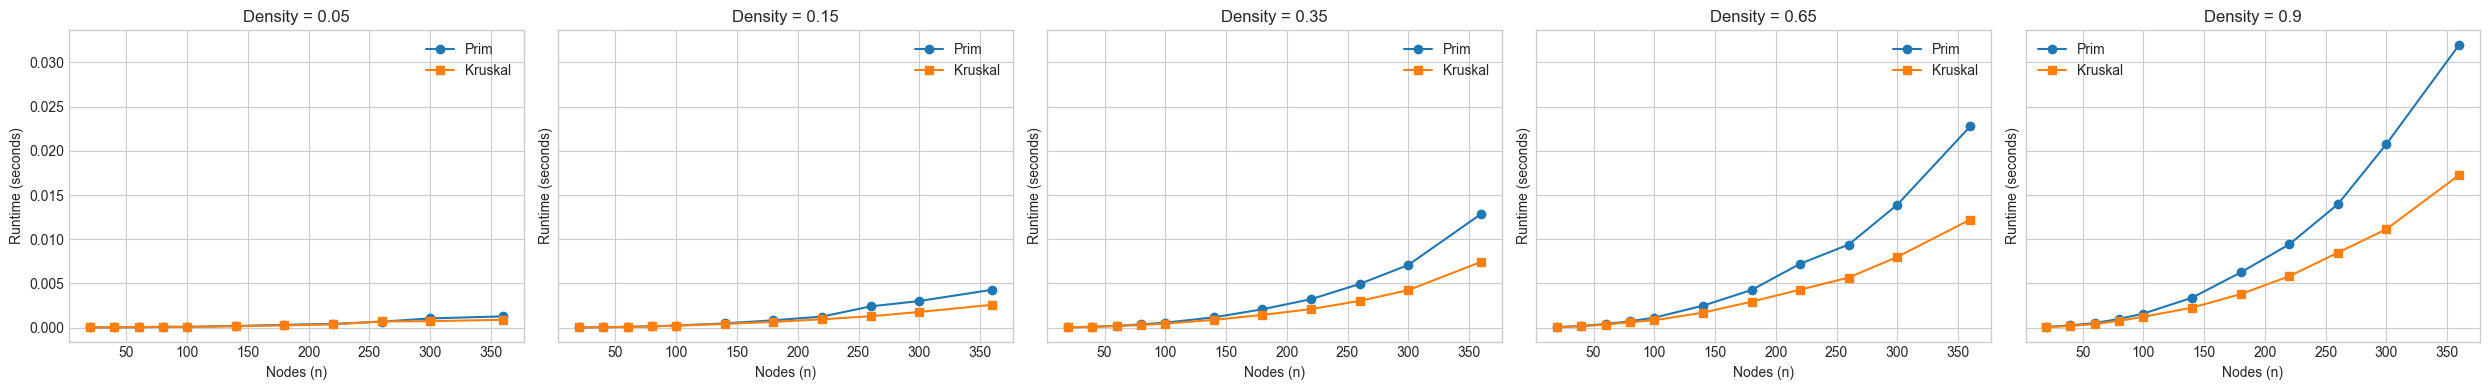

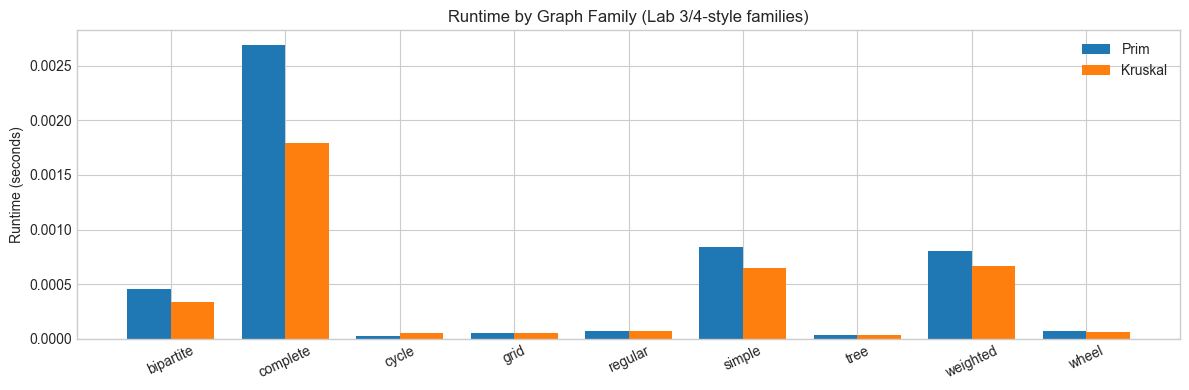

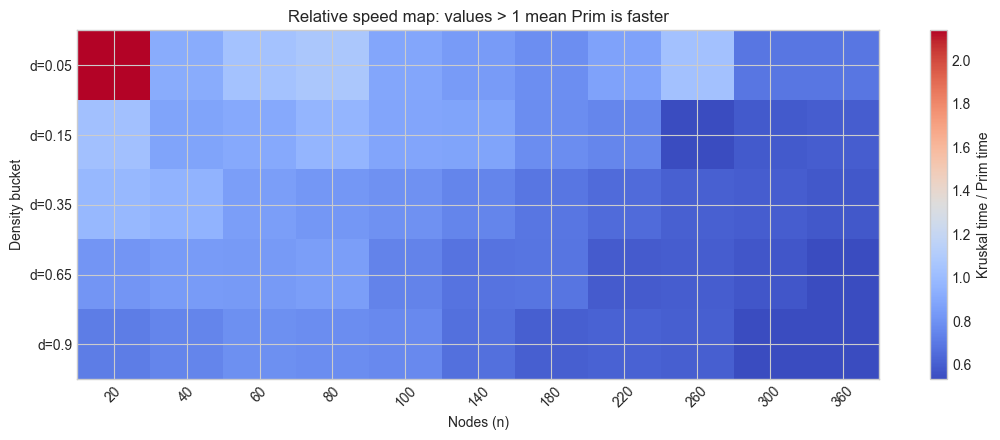

In [8]:
def filter_rows(rows, target_density):
    return [r for r in rows if abs(r["target_density"] - target_density) < 1e-12]


def plot_scale_curves(rows, densities):
    fig, axes = plt.subplots(1, len(densities), figsize=(5 * len(densities), 4), sharey=True)
    if len(densities) == 1:
        axes = [axes]

    for ax, d in zip(axes, densities):
        sub = sorted(filter_rows(rows, d), key=lambda x: x["n"])
        xs = [r["n"] for r in sub]
        yp = [r["prim_s"] for r in sub]
        yk = [r["kruskal_s"] for r in sub]

        ax.plot(xs, yp, marker="o", label="Prim")
        ax.plot(xs, yk, marker="s", label="Kruskal")
        ax.set_title(f"Density = {d}")
        ax.set_xlabel("Nodes (n)")
        ax.set_ylabel("Runtime (seconds)")
        ax.legend()

    plt.tight_layout()
    plt.show()


def plot_family_bars(rows):
    rows = sorted(rows, key=lambda x: x["family"])
    labels = [r["family"] for r in rows]
    yp = [r["prim_s"] for r in rows]
    yk = [r["kruskal_s"] for r in rows]

    x = list(range(len(labels)))
    w = 0.38

    plt.figure(figsize=(12, 4))
    plt.bar([i - w / 2 for i in x], yp, width=w, label="Prim")
    plt.bar([i + w / 2 for i in x], yk, width=w, label="Kruskal")
    plt.xticks(x, labels, rotation=25)
    plt.ylabel("Runtime (seconds)")
    plt.title("Runtime by Graph Family (Lab 3/4-style families)")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_speedup_heatmap(rows, node_sizes, densities):
    matrix = []
    for d in densities:
        row_vals = []
        for n in node_sizes:
            rec = next(r for r in rows if r["target_density"] == d and r["n"] == n)
            row_vals.append(rec["speedup_prim_over_kruskal"])
        matrix.append(row_vals)

    plt.figure(figsize=(11, 4.5))
    im = plt.imshow(matrix, aspect="auto", cmap="coolwarm")
    plt.colorbar(im, label="Kruskal time / Prim time")
    plt.xticks(list(range(len(node_sizes))), node_sizes, rotation=45)
    plt.yticks(list(range(len(densities))), [f"d={d}" for d in densities])
    plt.xlabel("Nodes (n)")
    plt.ylabel("Density bucket")
    plt.title("Relative speed map: values > 1 mean Prim is faster")
    plt.tight_layout()
    plt.show()


plot_scale_curves(scale_rows, densities)
plot_family_bars(family_rows)
plot_speedup_heatmap(scale_rows, node_sizes, densities)

In [9]:
def winner(row):
    return "Prim" if row["prim_s"] <= row["kruskal_s"] else "Kruskal"


def summarize_wins_by_target_density(rows):
    buckets = {}
    for r in rows:
        d = r["target_density"]
        if d not in buckets:
            buckets[d] = {"Prim": 0, "Kruskal": 0, "total": 0}
        w = winner(r)
        buckets[d][w] += 1
        buckets[d]["total"] += 1
    return buckets


wins = summarize_wins_by_target_density(scale_rows)

print("Winner distribution by target density:")
for d in sorted(wins):
    b = wins[d]
    print(f"- density={d:.2f}: Prim={b['Prim']}, Kruskal={b['Kruskal']}")

print("\nFamily-level snapshot:")
for r in sorted(family_rows, key=lambda x: x['family']):
    w = winner(r)
    print(f"- {r['family']:10s} | n={r['n']:3d}, m={r['m']:5d}, density={r['density']:.3f} | {w}")

Winner distribution by target density:
- density=0.05: Prim=4, Kruskal=7
- density=0.15: Prim=1, Kruskal=10
- density=0.35: Prim=0, Kruskal=11
- density=0.65: Prim=0, Kruskal=11
- density=0.90: Prim=0, Kruskal=11

Family-level snapshot:
- bipartite  | n=120, m= 1314, density=0.184 | Kruskal
- complete   | n=120, m= 7140, density=1.000 | Kruskal
- cycle      | n=120, m=  120, density=0.017 | Prim
- grid       | n=100, m=  180, density=0.036 | Kruskal
- regular    | n=120, m=  240, density=0.034 | Kruskal
- simple     | n=120, m= 2499, density=0.350 | Kruskal
- tree       | n=120, m=  119, density=0.017 | Prim
- weighted   | n=120, m= 2499, density=0.350 | Kruskal
- wheel      | n=120, m=  238, density=0.033 | Kruskal


## Short Report Template (Fill after execution)

### 1) Greedy method
- Prim and Kruskal are greedy algorithms: each step chooses a locally best edge.
- Prim grows one tree from a start vertex. Kruskal builds a forest by globally sorting edges.

### 2) Implemented algorithms
- Prim with min-heap over frontier edges.
- Kruskal with edge sorting + Disjoint Set Union (Union-Find).

### 3) Sparse vs dense analysis
- Use runtime curves for each density.
- Explain where sorting all edges (Kruskal) becomes more or less expensive than heap expansions (Prim).

### 4) Influence of node count
- Use runtime-vs-n plots and heatmap to explain complexity growth.
- Mention practical breakpoints observed on your machine.

### 5) Final recommendation
- State which algorithm is faster for sparse and dense graphs in your experiments.
- Include one practical rule for choosing Prim or Kruskal for a given graph type.

In [10]:
# Robustness check: larger instances, multiple random graphs, median timing
from statistics import median


def robust_scale_check(node_sizes, densities, graph_trials=5, repeats=5, seed=1234):
    results = []
    for d_idx, density in enumerate(densities):
        for n_idx, n in enumerate(node_sizes):
            prim_samples = []
            kruskal_samples = []
            same_weight_checks = []

            for t in range(graph_trials):
                random.seed(seed + 10_000 * d_idx + 1_000 * n_idx + t)
                adj, edges, m, real_density = generate_connected_random_weighted_graph(n, density)
                bench = benchmark_case(adj, edges, repeats=repeats)
                prim_samples.append(bench["prim_s"])
                kruskal_samples.append(bench["kruskal_s"])
                same_weight_checks.append(bench["same_total_weight"])

            prim_med = median(prim_samples)
            kruskal_med = median(kruskal_samples)

            results.append({
                "n": n,
                "density": density,
                "m": m,
                "real_density": real_density,
                "prim_median_s": prim_med,
                "kruskal_median_s": kruskal_med,
                "ratio_kr_over_prim": (kruskal_med / prim_med) if prim_med > 0 else float("inf"),
                "kruskal_wins": sum(1 for p, k in zip(prim_samples, kruskal_samples) if k < p),
                "prim_wins": sum(1 for p, k in zip(prim_samples, kruskal_samples) if p <= k),
                "all_same_weight": all(same_weight_checks),
            })
    return results


# Use bigger sizes than the main plot to reduce timer noise.
check_node_sizes = [200, 400, 600, 800]
check_densities = [0.05, 0.35, 0.90]

robust_rows = robust_scale_check(
    node_sizes=check_node_sizes,
    densities=check_densities,
    graph_trials=5,
    repeats=5,
)

print("Robust check (median over 5 random graphs, each timed with 5 repeats):")
for d in check_densities:
    print(f"\nDensity={d}")
    subset = [r for r in robust_rows if r["density"] == d]
    for r in subset:
        winner = "Kruskal" if r["kruskal_median_s"] < r["prim_median_s"] else "Prim"
        print(
            f"n={r['n']:4d} | Prim={r['prim_median_s']:.6f}s | "
            f"Kruskal={r['kruskal_median_s']:.6f}s | "
            f"K/P={r['ratio_kr_over_prim']:.3f} | winner={winner} | sameMST={r['all_same_weight']}"
        )

Robust check (median over 5 random graphs, each timed with 5 repeats):

Density=0.05
n= 200 | Prim=0.000352s | Kruskal=0.000270s | K/P=0.767 | winner=Kruskal | sameMST=True
n= 400 | Prim=0.001583s | Kruskal=0.001261s | K/P=0.797 | winner=Kruskal | sameMST=True
n= 600 | Prim=0.004543s | Kruskal=0.002815s | K/P=0.620 | winner=Kruskal | sameMST=True
n= 800 | Prim=0.007990s | Kruskal=0.004856s | K/P=0.608 | winner=Kruskal | sameMST=True

Density=0.35
n= 200 | Prim=0.002922s | Kruskal=0.001892s | K/P=0.648 | winner=Kruskal | sameMST=True
n= 400 | Prim=0.014515s | Kruskal=0.008268s | K/P=0.570 | winner=Kruskal | sameMST=True
n= 600 | Prim=0.040622s | Kruskal=0.019639s | K/P=0.483 | winner=Kruskal | sameMST=True
n= 800 | Prim=0.087912s | Kruskal=0.038610s | K/P=0.439 | winner=Kruskal | sameMST=True

Density=0.9
n= 200 | Prim=0.007911s | Kruskal=0.004836s | K/P=0.611 | winner=Kruskal | sameMST=True
n= 400 | Prim=0.043349s | Kruskal=0.021536s | K/P=0.497 | winner=Kruskal | sameMST=True
n= 600 |

In [11]:
# Fairness check: optimized Prim (key-based) vs current Prim and Kruskal

def prim_mst_key_based(adj):
    n = len(adj)
    visited = [False] * n
    best = [float("inf")] * n
    parent = [-1] * n
    total = 0
    mst_edges = []

    for start in range(n):
        if visited[start]:
            continue

        best[start] = 0
        heap = [(0, start)]

        while heap:
            w, u = heapq.heappop(heap)
            if visited[u] or w != best[u]:
                continue

            visited[u] = True
            if parent[u] != -1:
                total += w
                mst_edges.append((parent[u], u, w))

            for v, wt in adj[u]:
                if not visited[v] and wt < best[v]:
                    best[v] = wt
                    parent[v] = u
                    heapq.heappush(heap, (wt, v))

    return total, mst_edges


def compare_three_algorithms(n=800, density=0.35, trials=5, repeats=5, seed=777):
    rows = []
    for t in range(trials):
        random.seed(seed + t)
        adj, edges, m, _ = generate_connected_random_weighted_graph(n, density)

        t_prim_old, res_old = time_function(prim_mst, adj, repeats=repeats)
        t_prim_new, res_new = time_function(prim_mst_key_based, adj, repeats=repeats)
        t_kr, res_kr = time_function(kruskal_mst, n, edges, repeats=repeats)

        total_old = res_old[0]
        total_new = res_new[0]
        total_kr = res_kr[0]

        rows.append({
            "trial": t,
            "m": m,
            "prim_old_s": t_prim_old,
            "prim_new_s": t_prim_new,
            "kruskal_s": t_kr,
            "same_totals": abs(total_old - total_new) < 1e-9 and abs(total_new - total_kr) < 1e-9,
        })
    return rows


three_rows = compare_three_algorithms(n=800, density=0.35, trials=5, repeats=5)

print("Three-way timing check (n=800, density=0.35):")
for r in three_rows:
    print(
        f"trial={r['trial']} | oldPrim={r['prim_old_s']:.6f}s | "
        f"keyPrim={r['prim_new_s']:.6f}s | Kruskal={r['kruskal_s']:.6f}s | sameMST={r['same_totals']}"
    )

old_mean = sum(r["prim_old_s"] for r in three_rows) / len(three_rows)
new_mean = sum(r["prim_new_s"] for r in three_rows) / len(three_rows)
kr_mean = sum(r["kruskal_s"] for r in three_rows) / len(three_rows)

print("\nMeans over trials:")
print(f"old Prim mean: {old_mean:.6f}s")
print(f"key Prim mean: {new_mean:.6f}s")
print(f"Kruskal mean : {kr_mean:.6f}s")
print(f"keyPrim speedup over oldPrim: {old_mean / new_mean:.2f}x")
print(f"Kruskal / keyPrim ratio     : {kr_mean / new_mean:.2f}x")

Three-way timing check (n=800, density=0.35):
trial=0 | oldPrim=0.092158s | keyPrim=0.015518s | Kruskal=0.042308s | sameMST=True
trial=1 | oldPrim=0.093604s | keyPrim=0.016160s | Kruskal=0.039087s | sameMST=True
trial=2 | oldPrim=0.089599s | keyPrim=0.013923s | Kruskal=0.041038s | sameMST=True
trial=3 | oldPrim=0.125420s | keyPrim=0.026775s | Kruskal=0.048753s | sameMST=True
trial=4 | oldPrim=0.123811s | keyPrim=0.017136s | Kruskal=0.051558s | sameMST=True

Means over trials:
old Prim mean: 0.104918s
key Prim mean: 0.017902s
Kruskal mean : 0.044549s
keyPrim speedup over oldPrim: 5.86x
Kruskal / keyPrim ratio     : 2.49x
